In [1]:
from qiskit import QuantumCircuit, QuantumRegister, qpy

import rustworkx
from rustworkx.visualization import graphviz_draw
from rustworkx.rustworkx import simple_cycles
import collections
from collections import Counter
from typing import List
import copy


In [2]:
import os, sys

sys.path.append(os.path.abspath("../"))



In [3]:
from helperfunctions.reversecircuitgraph import uncomp_all_operations_using_bennetts_in_circuitgraph, remove_and_reorder_circuit_gates_simple
from helperfunctions.circuitgraphfunctions import get_computation_graph, get_uncomp_circuit
from helperfunctions.graphhelper import breakdown_qubit, edge_attr, node_attr, node_matcher, edge_matcher
from helperfunctions.uncompfunctions import add_uncomputation, add_uncomputation_step, remove_uncomputation_step
from helperfunctions.randomcircuit import random_quantum_circuit_varied_percentages, get_qubits_of_circuit

from helperfunctions.constants import StringConstants, ListConstants

In [4]:

INPUT = StringConstants.INPUT.value
ANCILLA = StringConstants.ANCILLA.value
OUTPUT = StringConstants.OUTPUT.value


INIT = StringConstants.INIT.value
COMP = StringConstants.COMP.value
UNCOMP = StringConstants.UNCOMP.value

In [5]:
def circ_func():
    circ = QuantumCircuit(QuantumRegister(2,'i'), QuantumRegister(2,'a'))
    circ.cx(0,2)
    circ.cx(1,3)
    circ.cx(2,1)
    circ.cx(3,0)

    return circ
    

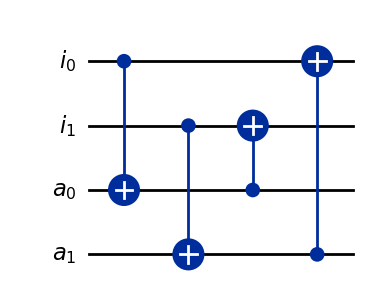

In [6]:
circ = circ_func()

circ.draw('mpl')

Adding Nodes for Circuit: 100%|██████████| 4/4 [00:00<00:00, 35696.20it/s]


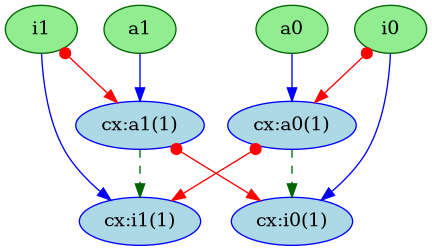

In [7]:
ancillae = get_qubits_of_circuit(circ, 2, ANCILLA)
cg = get_computation_graph(circ, ancillae)

graphviz_draw(cg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

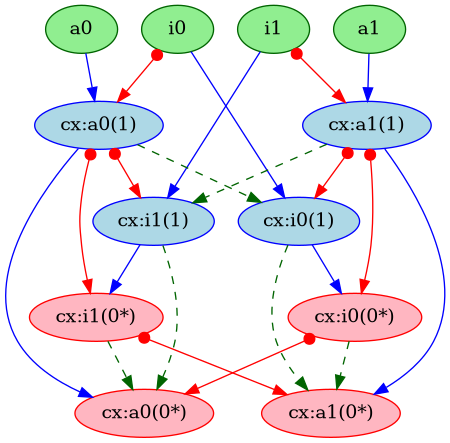

In [8]:
bennetts_ucg = uncomp_all_operations_using_bennetts_in_circuitgraph(cg)
graphviz_draw(bennetts_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

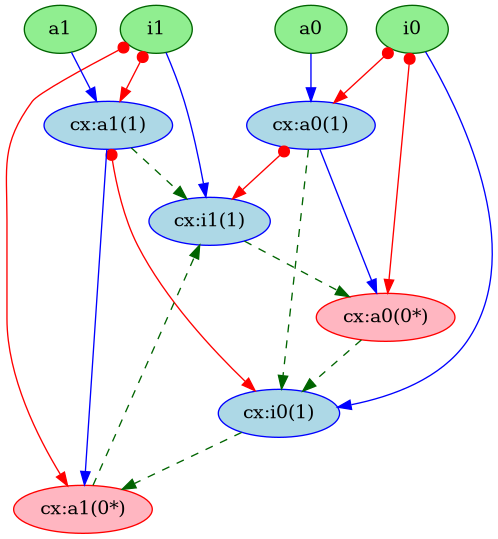

In [9]:
cyclic_ucg, has_cycles = add_uncomputation(cg, ancillae, allow_cycle=True)
graphviz_draw(cyclic_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

In [10]:
# def remove_and_reorder_circuit_gates_simple(bennetts_circuit_graph:rustworkx.PyDiGraph, cyclic_circuit_graph:rustworkx.PyDiGraph):
#     # We should not be needing the cyclic circuit graph

#     bennetts_circuit_graph = copy.deepcopy(bennetts_circuit_graph)
    
#     bennetts_nodes = list(bennetts_circuit_graph.node_indices())
#     bennetts_nodes.reverse()

#     bennetts_uncomp_copy = copy.deepcopy(bennetts_circuit_graph)

#     for idx in bennetts_nodes:
#         node = bennetts_circuit_graph.get_node_data(idx)
#         if node.qubit_type == INPUT and node.node_type == UNCOMP:
#             # print(node.simple_graph_label())
#             remove_uncomputation_step(bennetts_uncomp_copy, idx)

#             if rustworkx.digraph_find_cycle(bennetts_uncomp_copy):
#                 break
#             else:
#                 remove_uncomputation_step(bennetts_circuit_graph, idx)

#     return bennetts_circuit_graph  

In [11]:
new_bennetts_ucg = remove_and_reorder_circuit_gates_simple(bennetts_ucg)

Controlled by the node cx:i0(0*) : ['cx:a0(0*)']
Controlled by the node cx:i0(0*) : ['cx:a0(0*)']
Controlled by the node cx:i1(0*) : ['cx:a1(0*)']


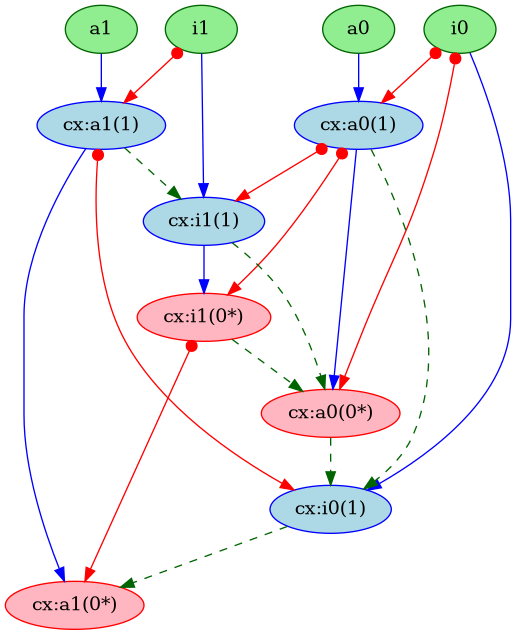

In [12]:
graphviz_draw(new_bennetts_ucg, node_attr_fn=node_attr, edge_attr_fn=edge_attr)

Building uncomp circuit from circuit graph: 100%|██████████| 11/11 [00:00<00:00, 47417.62it/s]


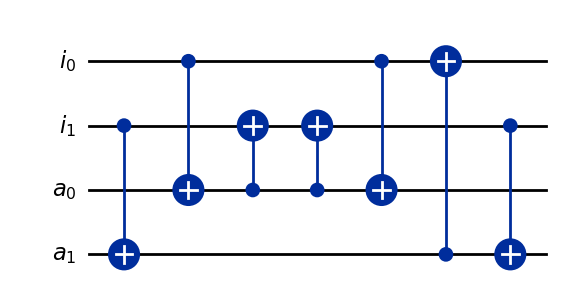

In [13]:
new_bennets_ucirc = get_uncomp_circuit(new_bennetts_ucg)

new_bennets_ucirc.draw('mpl')